# Sparse Latent Diffusion for Text — Colab Experiments

**Project:** Insert TopK Sparse Autoencoder into Cosmos latent text diffusion pipeline

**Pipeline:**
1. Download pretrained Cosmos checkpoints + ROCStories dataset
2. Extract normalized latents from frozen autoencoder
3. Train SAE (TopK) + Dense AE baseline on cached latents
4. Evaluate: baseline vs SAE-filtered vs Dense AE-filtered generation
5. (Optional) Scenario C: fine-tune diffusion with SAE targets

**Important:** Mount Google Drive to persist results across sessions.

## 0. Setup — Mount Drive & Clone Repo

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Persistent storage on Drive
DRIVE_PROJECT = '/content/drive/MyDrive/Cosmos_SAE'

import os
os.makedirs(DRIVE_PROJECT, exist_ok=True)
os.makedirs(f'{DRIVE_PROJECT}/checkpoints', exist_ok=True)
os.makedirs(f'{DRIVE_PROJECT}/cached_latents', exist_ok=True)
os.makedirs(f'{DRIVE_PROJECT}/sae_checkpoints', exist_ok=True)
os.makedirs(f'{DRIVE_PROJECT}/evaluation_results', exist_ok=True)
print("Drive mounted and directories ready.")

Mounted at /content/drive
Drive mounted and directories ready.


In [2]:
# Clone repo (fresh clone ensures latest code)
REPO_URL = "https://github.com/dbal0503/cosmos.git"

%cd /content
!rm -rf /content/cosmos
!git clone {REPO_URL} /content/cosmos
%cd /content/cosmos
!ls *.py

/content
Cloning into '/content/cosmos'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 107 (delta 32), reused 101 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 77.17 KiB | 7.01 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/cosmos
diffusion_trainer.py  extract_latents.py  train_diffusion.py	  train_sae.py
encoder_trainer.py    generate.py	  train_diffusion_sae.py
evaluate_sae.py       run_single_gpu.py   train_encoder.py


In [3]:
# Install dependencies
!pip install -q hydra-core omegaconf timm torch-ema torch-optimi rouge-score bert-score mauve-text sacrebleu datasets

# Verify GPU
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 83.5 MB/s eta 0:00:00:00:0100:01
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 14.6 GB


## 1. Download Pretrained Checkpoints

Cosmos checkpoints are hosted on AWS S3 (`s3://cosmos-latent-diffusion/checkpoints/`).
You need the autoencoder (trained on Wikipedia) and diffusion model (trained on ROCStories).

**If S3 requires credentials**, download manually and upload to `Drive/Cosmos_SAE/checkpoints/`.

In [4]:
!pip install -q awscli
import os

AE_CKPT = f"{DRIVE_PROJECT}/checkpoints/autoencoder-num_latents=16-wikipedia-final-128/100000.pth"
DIFF_CKPT = f"{DRIVE_PROJECT}/checkpoints/diffusion-rocstories-16-d=5-final/180000.pth"

# Autoencoder checkpoint
if not os.path.exists(AE_CKPT):
    !mkdir -p {DRIVE_PROJECT}/checkpoints/autoencoder-num_latents=16-wikipedia-final-128/
    !aws s3 cp s3://cosmos-latent-diffusion/checkpoints/autoencoder-num_latents=16-wikipedia-final-128/100000.pth \
        {AE_CKPT} --region eu-north-1 --no-sign-request
else:
    print(f"Autoencoder checkpoint already exists: {AE_CKPT}")

# Diffusion model checkpoint
if not os.path.exists(DIFF_CKPT):
    !mkdir -p {DRIVE_PROJECT}/checkpoints/diffusion-rocstories-16-d=5-final/
    !aws s3 cp s3://cosmos-latent-diffusion/checkpoints/diffusion-rocstories-16-d=5-final/180000.pth \
        {DIFF_CKPT} --region eu-north-1 --no-sign-request
else:
    print(f"Diffusion checkpoint already exists: {DIFF_CKPT}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 58.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 81.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
download: s3://cosmos-latent-diffusion/checkpoints/autoencoder-num_latents=16-wikipedia-final-128/100000.pth to ../drive/MyDrive/Cosmos_SAE/checkpoints/autoencoder-num_latents=16-wikipedia-final-128/100000.pth
download: s3://cosmos-latent-diffusion/checkpoints/diffusion-rocstories-16-d=5-final/180000.pth to ../drive/MyDrive/Cosmos_SAE/checkpoints/diffusion-rocstories-16-d=5-final/180000.pth


In [5]:
# Symlink Drive checkpoints into the repo's working directory
!ln -sfn {DRIVE_PROJECT}/checkpoints /content/cosmos/checkpoints

# Verify checkpoints exist
!ls -lh /content/cosmos/checkpoints/autoencoder-num_latents=16-wikipedia-final-128/
!ls -lh /content/cosmos/checkpoints/diffusion-rocstories-16-d=5-final/

total 3.1G
-rw------- 1 root root 3.1G Oct 12 10:21 100000.pth
total 2.5G
-rw------- 1 root root 2.5G Oct 12 10:24 180000.pth


## 2. Download ROCStories Dataset

Pre-processed datasets are on HuggingFace Hub under `bayes-group-diffusion`.
The Cosmos `load_to_hub.py` utility downloads and saves in the expected `.arrow` shard format.

In [6]:
from datasets import load_dataset
import os

DATA_DIR = "/content/cosmos/data/rocstories"

if not os.path.exists(DATA_DIR):
    print("Downloading ROCStories from HuggingFace Hub...")
    ds = load_dataset("bayes-group-diffusion/rocstories")
    ds.save_to_disk(DATA_DIR)
    print(f"Saved to {DATA_DIR}")
else:
    print(f"Dataset already exists at {DATA_DIR}")

# Verify structure
!ls -la {DATA_DIR}/
!ls {DATA_DIR}/train/ | head -5
!ls {DATA_DIR}/test/ | head -5

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/380 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/12.9M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.45M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/88161 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/88161 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/10000 [00:00<?, ? examples/s]

Saved to /content/cosmos/data/rocstories
total 20
drwxr-xr-x 4 root root 4096 Apr  3 15:52 .
drwxr-xr-x 3 root root 4096 Apr  3 15:52 ..
-rw-r--r-- 1 root root   29 Apr  3 15:52 dataset_dict.json
drwxr-xr-x 2 root root 4096 Apr  3 15:52 test
drwxr-xr-x 2 root root 4096 Apr  3 15:52 train
data-00000-of-00001.arrow
dataset_info.json
state.json
data-00000-of-00001.arrow
dataset_info.json
state.json


## 3. Extract Latents from Frozen Autoencoder

Runs the frozen Cosmos autoencoder over ROCStories, saves normalized latents as `.pt` files.
This decouples SAE training from the autoencoder — only needs to run once.

**Runtime:** ~15-30 min on T4 depending on dataset size.
**Output:** `cached_latents/rocstories/{train,test}/latents_*.pt`

In [7]:
%cd /content/cosmos

!HYDRA_FULL_ERROR=1 python extract_latents.py \
    dataset=rocstories \
    encoder.latent.num_latents=16 \
    encoder.embedding.max_position_embeddings=128 \
    decoder.latent.num_latents=16 \
    decoder.embedding.max_position_embeddings=128 \
    autoencoder.model.load_checkpoint='"autoencoder-num_latents=16-wikipedia-final-128/100000.pth"'

/content/cosmos
[2026-04-03 15:53:08,805][extract_latents][INFO] - [rank=0] Using device: cuda
[2026-04-03 15:53:08,806][extract_latents][INFO] - [rank=0] Loading autoencoder...
[2026-04-03 15:53:08,970][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/bert-base-cased/resolve/main/config.json "HTTP/1.1 200 OK"
[2026-04-03 15:53:09,057][httpx][INFO] - HTTP Request: GET https://huggingface.co/bert-base-cased/resolve/main/config.json "HTTP/1.1 200 OK"
config.json: 100% 570/570 [00:00<00:00, 2.46MB/s]
[2026-04-03 15:53:09,141][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/bert-base-cased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
[2026-04-03 15:53:09,222][httpx][INFO] - HTTP Request: GET https://huggingface.co/bert-base-cased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
tokenizer_config.json: 100% 49.0/49.0 [00:00<00:00, 311kB/s]
[2026-04-03 15:53:09,300][httpx][INFO] - HTTP Request: GET https://huggingface.co/api/models/bert-base-cased/tree/main/additi

In [8]:
# Persist cached latents to Drive (so you never need to re-extract)
!cp -r /content/cosmos/cached_latents {DRIVE_PROJECT}/

# Verify
!ls -lh /content/cosmos/cached_latents/rocstories/train/
!ls -lh /content/cosmos/cached_latents/rocstories/test/

total 4.1G
-rw-r--r-- 1 root root 472M Apr  3 15:54 latents_0000.pt
-rw-r--r-- 1 root root 472M Apr  3 15:56 latents_0001.pt
-rw-r--r-- 1 root root 472M Apr  3 15:57 latents_0002.pt
-rw-r--r-- 1 root root 472M Apr  3 15:59 latents_0003.pt
-rw-r--r-- 1 root root 472M Apr  3 16:00 latents_0004.pt
-rw-r--r-- 1 root root 472M Apr  3 16:02 latents_0005.pt
-rw-r--r-- 1 root root 472M Apr  3 16:03 latents_0006.pt
-rw-r--r-- 1 root root 472M Apr  3 16:05 latents_0007.pt
-rw-r--r-- 1 root root 365M Apr  3 16:06 latents_0008.pt
total 469M
-rw-r--r-- 1 root root 469M Apr  3 16:08 latents_0000.pt


### (Session resume) Restore cached latents from Drive
Run this cell instead of Step 3 if you already extracted latents in a previous session.

In [9]:
# Only run this if resuming from a previous session
!cp -r {DRIVE_PROJECT}/cached_latents /content/cosmos/
!ls -lh /content/cosmos/cached_latents/rocstories/train/

total 4.1G
-rw-r--r-- 1 root root 472M Apr  3 16:09 latents_0000.pt
-rw-r--r-- 1 root root 472M Apr  3 16:09 latents_0001.pt
-rw-r--r-- 1 root root 472M Apr  3 16:09 latents_0002.pt
-rw-r--r-- 1 root root 472M Apr  3 16:09 latents_0003.pt
-rw-r--r-- 1 root root 472M Apr  3 16:09 latents_0004.pt
-rw-r--r-- 1 root root 472M Apr  3 16:09 latents_0005.pt
-rw-r--r-- 1 root root 472M Apr  3 16:09 latents_0006.pt
-rw-r--r-- 1 root root 472M Apr  3 16:09 latents_0007.pt
-rw-r--r-- 1 root root 365M Apr  3 16:09 latents_0008.pt


## 4. Train SAE on Cached Latents

Train TopK SAE and Dense AE baseline on the extracted latents.
This is lightweight — only operates on cached tensors (no autoencoder needed).

**Runtime:** ~20-30 min for 50k steps on T4.
**VRAM:** ~1 GB.

In [10]:
# 4a. Train TopK SAE (expansion=4x, k=64)
%cd /content/cosmos

!python train_sae.py \
    --latents_dir cached_latents/rocstories \
    --sae_type topk \
    --expansion_factor 4 \
    --k 64 \
    --lr 3e-4 \
    --batch_size 4096 \
    --num_steps 50000 \
    --log_every 100 \
    --eval_every 1000 \
    --checkpoint_every 5000 \
    --output_dir sae_checkpoints/topk_4x_k64

/content/cosmos
Using device: cuda
Loaded 88161 latents from 9 files, shape: torch.Size([88161, 16, 768])
Flattened: 1410576 vectors of dim 768
Loaded 10000 latents from 1 files, shape: torch.Size([10000, 16, 768])
Validation: 160000 vectors
SAE parameters: 4,722,432
SAE hidden dim: 3072, k=64
MSE=0.376957 FVU=0.3355 L0=64.0 Dead(ema)=0.000:   2% 999/50000 [00:40<27:26, 29.76it/s]  
[Step 1000] Val MSE=0.379157 Val FVU=0.3377
  -> New best FVU: 0.3377
MSE=0.308206 FVU=0.2741 L0=64.0 Dead(ema)=0.000:   4% 1999/50000 [01:23<28:39, 27.91it/s]  
[Step 2000] Val MSE=0.308375 Val FVU=0.2748
  -> New best FVU: 0.2748
MSE=0.276572 FVU=0.2468 L0=64.0 Dead(ema)=0.000:   6% 2999/50000 [02:05<26:00, 30.11it/s]  
[Step 3000] Val MSE=0.281950 Val FVU=0.2511
  -> New best FVU: 0.2511
MSE=0.269318 FVU=0.2396 L0=64.0 Dead(ema)=0.000:   8% 3997/50000 [02:48<26:44, 28.67it/s]  
[Step 4000] Val MSE=0.268330 Val FVU=0.2391
  -> New best FVU: 0.2391
MSE=0.261447 FVU=0.2321 L0=64.0 Dead(ema)=0.000:  10% 4997

In [11]:
# 4b. Train Dense AE baseline (same architecture, ReLU instead of TopK)
!python train_sae.py \
    --latents_dir cached_latents/rocstories \
    --sae_type dense \
    --expansion_factor 4 \
    --lr 3e-4 \
    --batch_size 4096 \
    --num_steps 50000 \
    --log_every 100 \
    --eval_every 1000 \
    --checkpoint_every 5000 \
    --output_dir sae_checkpoints/dense_4x

Using device: cuda
Loaded 88161 latents from 9 files, shape: torch.Size([88161, 16, 768])
Flattened: 1410576 vectors of dim 768
Loaded 10000 latents from 1 files, shape: torch.Size([10000, 16, 768])
Validation: 160000 vectors
SAE parameters: 4,722,432
SAE hidden dim: 3072, k=N/A
MSE=0.184285 FVU=0.1644 L0=704.6 Dead(ema)=0.000:   2% 997/50000 [00:39<37:49, 21.59it/s]  
[Step 1000] Val MSE=0.186583 Val FVU=0.1663
  -> New best FVU: 0.1663
MSE=0.013284 FVU=0.0119 L0=942.2 Dead(ema)=0.000:   4% 1998/50000 [01:20<27:53, 28.69it/s]  
[Step 2000] Val MSE=0.013562 Val FVU=0.0121
  -> New best FVU: 0.0121
MSE=0.004153 FVU=0.0037 L0=941.4 Dead(ema)=0.000:   6% 2999/50000 [02:01<25:28, 30.75it/s]  
[Step 3000] Val MSE=0.004954 Val FVU=0.0044
  -> New best FVU: 0.0044
MSE=0.002733 FVU=0.0024 L0=941.6 Dead(ema)=0.000:   8% 3999/50000 [02:42<25:08, 30.49it/s]  
[Step 4000] Val MSE=0.003125 Val FVU=0.0028
  -> New best FVU: 0.0028
MSE=0.001137 FVU=0.0010 L0=941.2 Dead(ema)=0.000:  10% 4996/50000 [03

In [12]:
# Persist SAE checkpoints to Drive
!cp -r /content/cosmos/sae_checkpoints {DRIVE_PROJECT}/
print("SAE checkpoints saved to Drive.")

SAE checkpoints saved to Drive.


## 5. Inspect SAE Training Results

Quick sanity check: plot training curves and verify reconstruction quality before evaluation.

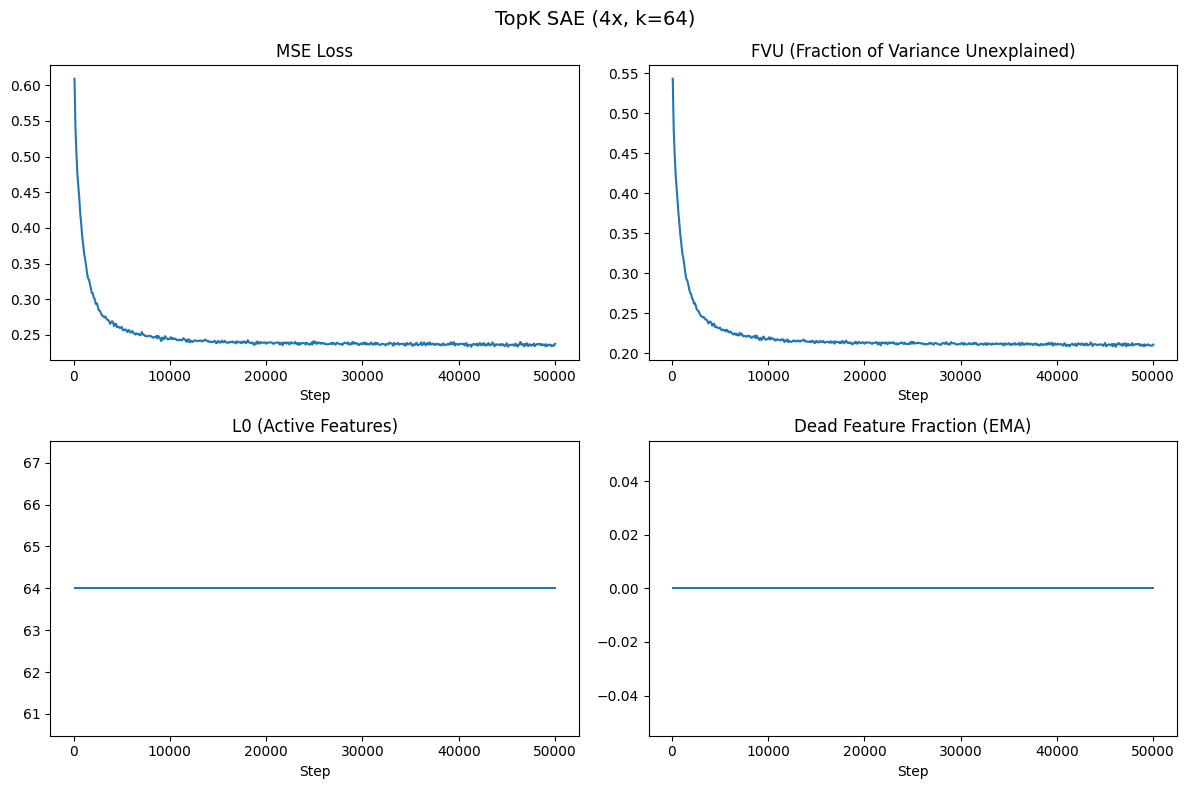

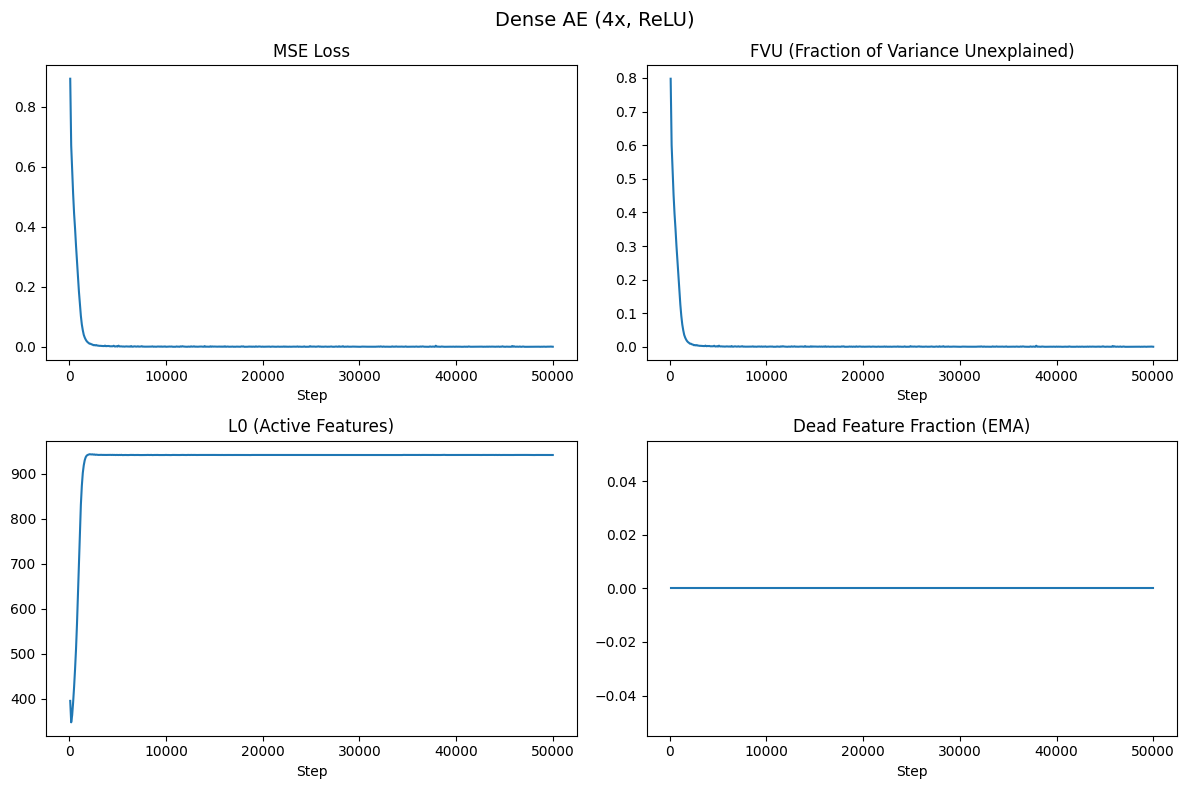

In [13]:
import json
import matplotlib.pyplot as plt

def plot_training_log(log_path, label):
    with open(log_path) as f:
        log = json.load(f)

    steps = [e["step"] for e in log]
    mse = [e["mse"] for e in log]
    fvu = [e["fvu"] for e in log]
    l0 = [e["l0"] for e in log]
    dead = [e["dead_frac_ema"] for e in log]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(label, fontsize=14)

    axes[0, 0].plot(steps, mse)
    axes[0, 0].set_title("MSE Loss")
    axes[0, 0].set_xlabel("Step")

    axes[0, 1].plot(steps, fvu)
    axes[0, 1].set_title("FVU (Fraction of Variance Unexplained)")
    axes[0, 1].set_xlabel("Step")

    axes[1, 0].plot(steps, l0)
    axes[1, 0].set_title("L0 (Active Features)")
    axes[1, 0].set_xlabel("Step")

    axes[1, 1].plot(steps, dead)
    axes[1, 1].set_title("Dead Feature Fraction (EMA)")
    axes[1, 1].set_xlabel("Step")

    plt.tight_layout()
    plt.show()

# Plot both training runs
plot_training_log("sae_checkpoints/topk_4x_k64/training_log.json", "TopK SAE (4x, k=64)")
plot_training_log("sae_checkpoints/dense_4x/training_log.json", "Dense AE (4x, ReLU)")

## 6. Evaluate: Baseline vs SAE vs Dense AE

Runs generation with all three variants and compares MAUVE, diversity, PPL, and rounding error.
Requires the full pipeline (autoencoder + diffusion model).

**Runtime:** ~30-60 min for 2000 texts on T4.
**VRAM:** ~12 GB (tight on T4 — reduce `--num_texts` or `--batch_size` if OOM).

## 6. Evaluate: Baseline vs SAE vs Dense AE

Runs generation with all three variants and compares MAUVE, diversity, PPL, and rounding error.
Requires the full pipeline (autoencoder + diffusion model).

**Runtime:** ~30-60 min for 2000 texts on T4.
**VRAM:** ~12 GB (tight on T4 — reduce `--num_texts` or `--batch_size` if OOM).

In [14]:
%cd /content/cosmos

!HYDRA_FULL_ERROR=1 python evaluate_sae.py \
    --dataset rocstories \
    --autoencoder_ckpt "autoencoder-num_latents=16-wikipedia-final-128/100000.pth" \
    --diffusion_ckpt "diffusion-rocstories-16-d=5-final/180000.pth" \
    --sae_ckpt sae_checkpoints/topk_4x_k64/best.pt \
    --dense_ckpt sae_checkpoints/dense_4x/best.pt \
    --sae_type topk \
    --expansion_factor 4 \
    --k 64 \
    --num_texts 2000 \
    --batch_size 32 \
    --output_dir evaluation_results

/content/cosmos
Traceback (most recent call last):
  File "/content/cosmos/evaluate_sae.py", line 343, in <module>
    main()
  File "/content/cosmos/evaluate_sae.py", line 230, in main
    from diffusion_trainer import DiffusionTrainer
  File "/content/cosmos/diffusion_trainer.py", line 26, in <module>
    from estimation.metrics import compute_metric
  File "/content/cosmos/estimation/metrics.py", line 4, in <module>
    from evaluate import load
ModuleNotFoundError: No module named 'evaluate'


In [15]:
# Display results table
import json

with open("evaluation_results/evaluation_results.json") as f:
    results = json.load(f)

# Print formatted comparison
print(f"{'Metric':<25} {'Baseline':>12} {'SAE':>12} {'Dense AE':>12}")
print("-" * 65)
for metric in ["mauve", "diversity", "ppl", "rounding_error_mean", "rounding_error_median"]:
    row = f"{metric:<25}"
    for model in ["baseline", "sae", "dense_ae"]:
        val = results.get(model, {}).get(metric)
        if val is not None and isinstance(val, (int, float)):
            row += f"{val:>12.5f}"
        else:
            row += f"{'N/A':>12}"
    print(row)

FileNotFoundError: [Errno 2] No such file or directory: 'evaluation_results/evaluation_results.json'

In [ ]:
# Persist evaluation results to Drive
!cp -r /content/cosmos/evaluation_results {DRIVE_PROJECT}/
print("Results saved to Drive.")

## 7. (Optional) Scenario C — Fine-tune Diffusion with SAE Targets

Fine-tunes the pretrained diffusion model so it learns to predict SAE-reconstructed
latents directly. This is the strongest integration — the diffusion model's outputs
will naturally land on the SAE's manifold.

**Runtime:** ~1-2 hours for 20k steps on T4.
**VRAM:** ~14 GB (may need A100 on Colab Pro).

In [ ]:
%cd /content/cosmos

!HYDRA_FULL_ERROR=1 python train_diffusion_sae.py \
    dataset=rocstories \
    encoder.latent.num_latents=16 \
    encoder.embedding.max_position_embeddings=128 \
    decoder.latent.num_latents=16 \
    decoder.embedding.max_position_embeddings=128 \
    autoencoder.model.load_checkpoint='"autoencoder-num_latents=16-wikipedia-final-128/100000.pth"' \
    diffusion.model.load_checkpoint='"diffusion-rocstories-16-d=5-final/180000.pth"' \
    diffusion.training.batch_size=64 \
    training=diffusion \
    suffix=sae-finetune \
    +sae_checkpoint=sae_checkpoints/topk_4x_k64/best.pt \
    +sae_type=topk \
    +sae_expansion_factor=4 \
    +sae_k=64 \
    +finetune_lr=1e-5 \
    +finetune_steps=20000

In [ ]:
# Persist fine-tuned diffusion checkpoints to Drive
!cp -r /content/cosmos/checkpoints/diffusion*sae-finetune* {DRIVE_PROJECT}/checkpoints/ 2>/dev/null
print("Fine-tuned checkpoints saved to Drive.")

## 8. SAE Hyperparameter Sweep (Optional)

Try different expansion factors and k values to find the best configuration.

In [ ]:
import subprocess

# Hyperparameter grid
configs = [
    {"expansion_factor": 2, "k": 32,  "name": "topk_2x_k32"},
    {"expansion_factor": 4, "k": 64,  "name": "topk_4x_k64"},   # default
    {"expansion_factor": 4, "k": 128, "name": "topk_4x_k128"},
    {"expansion_factor": 8, "k": 64,  "name": "topk_8x_k64"},
    {"expansion_factor": 8, "k": 128, "name": "topk_8x_k128"},
]

for cfg in configs:
    output_dir = f"sae_checkpoints/{cfg['name']}"
    print(f"\n{'='*60}")
    print(f"Training: {cfg['name']} (expansion={cfg['expansion_factor']}, k={cfg['k']})")
    print(f"{'='*60}")

    cmd = [
        "python", "train_sae.py",
        "--latents_dir", "cached_latents/rocstories",
        "--sae_type", "topk",
        "--expansion_factor", str(cfg["expansion_factor"]),
        "--k", str(cfg["k"]),
        "--lr", "3e-4",
        "--batch_size", "4096",
        "--num_steps", "50000",
        "--output_dir", output_dir,
    ]
    subprocess.run(cmd)

# Copy all results to Drive
!cp -r /content/cosmos/sae_checkpoints {DRIVE_PROJECT}/

In [ ]:
# Compare sweep results — best FVU from each config
import json, os

print(f"{'Config':<25} {'Best FVU':>10} {'Final MSE':>12} {'Final L0':>10}")
print("-" * 60)

for cfg in configs:
    log_path = f"sae_checkpoints/{cfg['name']}/training_log.json"
    if not os.path.exists(log_path):
        continue
    with open(log_path) as f:
        log = json.load(f)
    best_fvu = min(e["fvu"] for e in log)
    final = log[-1]
    print(f"{cfg['name']:<25} {best_fvu:>10.4f} {final['mse']:>12.6f} {final['l0']:>10.1f}")